# Fast Agent - Build a SQL Agent fast!

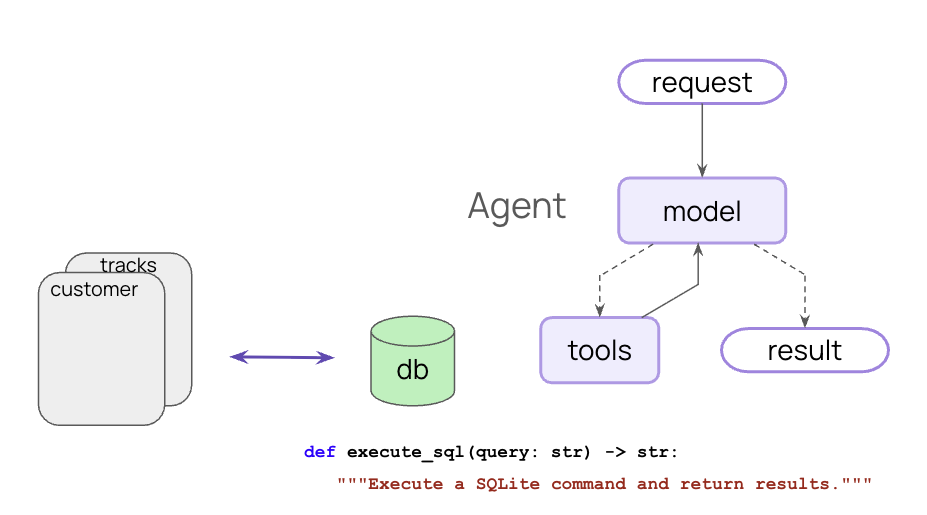

## Setup

Load and/or check for needed environmental variables

In [1]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [2]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0, http_client=http_client)

In [3]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.

In [4]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [5]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [6]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list. 

In [8]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

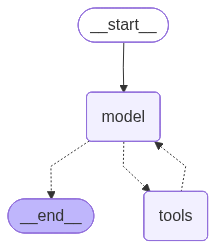

In [9]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [10]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (6yggk9az5)
 Call ID: 6yggk9az5
  Args:
    query: SELECT tbl_name, COUNT(*) as count FROM sqlite_master WHERE type='table' GROUP BY tbl_name ORDER BY count DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

[('Track', 1)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (6jt0fcg4g)
 Call ID: 6jt0fcg4g
  Args:
    query: SELECT name, rowid FROM sqlite_master WHERE type='table' ORDER BY rootpage DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

[('Track', 12)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (4rfahhp

In [11]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (8f0d320fn)
 Call ID: 8f0d320fn
  Args:
    query: SELECT genre, AVG(duration) as avg_duration FROM tracks GROUP BY genre ORDER BY avg_duration DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: tracks
[SQL: SELECT genre, AVG(duration) as avg_duration FROM tracks GROUP BY genre ORDER BY avg_duration DESC LIMIT 1;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==================================
Tool Calls:
  execute_sql (nxxh7tygq)
 Call ID: nxxh7tygq
  Args:
    query: SELECT genre, AVG(duration) as avg_duration FROM genres GROUP BY genre ORDER BY avg_duration DESC LIMIT 1;
==========

In [10]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_l1UWwgSfPDbtNMgiOqdd1QHf)
 Call ID: call_l1UWwgSfPDbtNMgiOqdd1QHf
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_XVZ2quL9z2LYrw1gb6jknw5L)
 Call ID: call_XVZ2quL9z2LYrw1gb6jknw5L
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('

**Create your own query here!**  Add some questions of your own.

In [ ]:
question = "TRY YOUR OWN QUERY HERE"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

### Let's try this Studio